# ***Retail Sales Analysis: Exploring Walmart Store Performance and Holiday Impact***

---



###**Executive Summary**

- Sales performance varies considerably across Walmart's 45 stores, showing that company-wide averages can hide important differences between locations.
- Holiday weeks recorded higher average sales than regular weeks, with a paired-samples t-test showing a statistically significant difference across stores.
- Temperature, fuel prices, CPI, and unemployment showed weak standalone linear relationships with weekly sales, suggesting that store-level differences and seasonal timing are more informative within this dataset.



### **Project Objective**

This project analyzes Walmart sales data across 45 stores to identify key trends in store performance, seasonal sales patterns, and holiday activity.

Using Python, SQL, and statistical analysis, the project examines which stores generate the strongest sales, how sales change over time, and whether factors such as holidays, temperature, fuel prices, CPI, and unemployment are associated with weekly sales.

The goal is to turn the data into practical insights that could support decisions related to inventory planning, staffing, and overall store performance.


---



In [37]:
import pandas as pd
import sqlite3
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
#The following libraries are used for data analysis, SQL querying, statistical testing, and visualization.

In [38]:
from google.colab import files
uploaded = files.upload()

filename = next(iter(uploaded))

Saving walmart-sales-dataset.csv to walmart-sales-dataset.csv


In [39]:
df = pd.read_csv("walmart-sales-dataset.csv")

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106



---
# **Data Quality and Cleaning:**


**Number of Rows and Columns**

In [40]:
df.shape

(6435, 8)

**Checking For Missing Values, Duplicates and Data Type:**

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [42]:
df.duplicated().sum()

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [43]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


The statistical summary provides an overview of the dataset, including the average, standard deviation, minimum, maximum, and quartile values for each numerical variable. These values help confirm that the dataset was loaded correctly and provide an initial understanding of the range and distribution of the data.

# Convert Date from text (DD-MM-YYYY) into a proper datetime datatype:

In [44]:
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%d-%m-%Y"
)
df.dtypes

,0
Store,int64
Date,datetime64[ns]
Weekly_Sales,float64
Holiday_Flag,int64
Temperature,float64
Fuel_Price,float64
CPI,float64
Unemployment,float64


# Date Range:

In [45]:
print("Earliest Date:", df["Date"].min())
print("Latest Date:", df["Date"].max())

Earliest Date: 2010-02-05 00:00:00
Latest Date: 2012-10-26 00:00:00


In [46]:
df = df.sort_values(
    by=["Store", "Date"]
).reset_index(drop=True)
df.head(5)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106




---


**Calculating Total Sales:**

In [47]:
total_sales = df['Weekly_Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 6737218987.11




---


# **Loading the Data into SQLite:**

In [48]:
conn = sqlite3.connect("walmart.db")
df.to_sql("walmart_sales", conn, if_exists="replace", index=False)


6435

In [49]:
query = """
SELECT *
FROM walmart_sales
LIMIT 10;
"""
pd.read_sql_query(query, conn)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05 00:00:00,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12 00:00:00,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19 00:00:00,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26 00:00:00,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05 00:00:00,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-03-12 00:00:00,1439541.59,0,57.79,2.667,211.380643,8.106
6,1,2010-03-19 00:00:00,1472515.79,0,54.58,2.720,211.215635,8.106
7,1,2010-03-26 00:00:00,1404429.92,0,51.45,2.732,211.018042,8.106
8,1,2010-04-02 00:00:00,1594968.28,0,62.27,2.719,210.820450,7.808
9,1,2010-04-09 00:00:00,1545418.53,0,65.86,2.770,210.622857,7.808


**Validating the SQLite:**

1. Counting rows

In [50]:
pd.read_sql_query("""
SELECT COUNT(*) AS Row_Count
FROM walmart_sales;
""", conn)

,Row_Count
0,6435


2. Verifing the date range matches the original Dataset

In [51]:
pd.read_sql_query("""
SELECT MIN(Date) AS Earliest_Date, MAX(Date) AS Latest_Date
FROM walmart_sales;
""", conn)

,Earliest_Date,Latest_Date
0,2010-02-05 00:00:00,2012-10-26 00:00:00


3. Number of Stores on the sql table:

In [52]:
pd.read_sql_query("""
SELECT COUNT(DISTINCT Store) AS Number_of_Stores
FROM walmart_sales;
""", conn)

,Number_of_Stores
0,45


4. Verifing summary statistics against the original dataset

In [53]:
pd.read_sql_query("""
SELECT MIN(Weekly_Sales) AS Min_Sales, MAX(Weekly_Sales) AS Max_Sales, AVG(Weekly_Sales) AS Avg_Sales, SUM(Weekly_Sales) AS Total_Sales
FROM walmart_sales;
""", conn)

,Min_Sales,Max_Sales,Avg_Sales,Total_Sales
0,209986.25,3818686.45,1.046965e+06,6.737219e+09


5. Checking SQL column data types

In [54]:
pd.read_sql_query("""
PRAGMA table_info(walmart_sales);
""", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Store,INTEGER,0,None,0
1,1,Date,TIMESTAMP,0,None,0
2,2,Weekly_Sales,REAL,0,None,0
3,3,Holiday_Flag,INTEGER,0,None,0
4,4,Temperature,REAL,0,None,0
5,5,Fuel_Price,REAL,0,None,0
6,6,CPI,REAL,0,None,0
7,7,Unemployment,REAL,0,None,0




---


# **Overall Sales KPIs:**

In [55]:
pd.read_sql_query("""
SELECT AVG(Weekly_Sales) AS Avg_weekly_sales, SUM(Weekly_Sales) AS Total_Sales
FROM walmart_sales;
""", conn)

,Avg_weekly_sales,Total_Sales
0,1.046965e+06,6.737219e+09





**Total Sales by Each Store:**

This analysis calculates the total sales generated by each store and ranks the stores from highest to lowest based on overall sales performance.


In [56]:
pd.read_sql_query("""
SELECT Store, SUM(Weekly_Sales) AS Total_Sales, RANK() OVER (ORDER BY SUM(Weekly_Sales) DESC) AS Sales_Rank
FROM walmart_sales
GROUP BY Store
ORDER BY Sales_Rank;
""",conn)

,Store,Total_Sales,Sales_Rank
0,20,3.013978e+08,1
1,4,2.995440e+08,2
2,14,2.889999e+08,3
3,13,2.865177e+08,4
4,2,2.753824e+08,5
5,10,2.716177e+08,6
6,27,2.538559e+08,7
7,6,2.237561e+08,8
8,1,2.224028e+08,9
9,39,2.074455e+08,10


**The Average Weekly Sales by Each Store:**

This analysis calculates the average weekly sales for each of the 45 stores to compare typical sales performance across locations.

In [57]:
pd.read_sql_query("""
SELECT Store, AVG(Weekly_Sales) AS Avg_Weekly_Sales
FROM walmart_sales
GROUP BY Store
Order by Avg_Weekly_Sales DESC

  """, conn)

,Store,Avg_Weekly_Sales
0,20,2.107677e+06
1,4,2.094713e+06
2,14,2.020978e+06
3,13,2.003620e+06
4,2,1.925751e+06
5,10,1.899425e+06
6,27,1.775216e+06
7,6,1.564728e+06
8,1,1.555264e+06
9,39,1.450668e+06


# Store Performance Compared With the Overall Average



To better understand store-level performance, each store’s average weekly sales are compared with the overall average weekly sales across all store-week observations.

Average weekly sales of 45 stores is \$1.047 million

In [58]:
pd.read_sql_query("""
SELECT Store, AVG(Weekly_Sales) AS Avg_Weekly_Sales_of_each_store, AVG(Weekly_Sales) - (
    SELECT AVG(Weekly_Sales) FROM walmart_sales) AS Difference_From_Overall_Avg,
    CASE
        WHEN AVG(Weekly_Sales) >= (
            SELECT AVG(Weekly_Sales)
            FROM walmart_sales
        )
        THEN 'Above Average'
        ELSE 'Below Average'
    END AS Performance
FROM walmart_sales
GROUP BY Store
ORDER BY Difference_From_Overall_Avg DESC;
""",conn)

,Store,Avg_Weekly_Sales_of_each_store,Difference_From_Overall_Avg,Performance
0,20,2.107677e+06,1.060712e+06,Above Average
1,4,2.094713e+06,1.047748e+06,Above Average
2,14,2.020978e+06,9.740135e+05,Above Average
3,13,2.003620e+06,9.566554e+05,Above Average
4,2,1.925751e+06,8.787865e+05,Above Average
5,10,1.899425e+06,8.524597e+05,Above Average
6,27,1.775216e+06,7.282513e+05,Above Average
7,6,1.564728e+06,5.177633e+05,Above Average
8,1,1.555264e+06,5.082995e+05,Above Average
9,39,1.450668e+06,4.037033e+05,Above Average


A positive difference indicates that a store performs above the overall average, while a negative difference indicates that it performs below the overall average.



---

# **Time-Based Analysis:**

**Total Sales by Year:**


This analysis examines Walmart’s sales performance across the years included in the dataset. Because 2010 and 2012 contain fewer observed weeks than 2011, total annual sales should be interpreted alongside the number of weeks available for each year. Average weekly sales provide a more comparable measure of performance across years.

In [59]:
pd.read_sql_query("""
SELECT
    strftime('%Y', Date) AS Year,
    COUNT(DISTINCT Date) AS Weeks_Observed,
    SUM(Weekly_Sales) AS Total_Sales,
    AVG(Weekly_Sales) AS Avg_Weekly_Sales
FROM walmart_sales
GROUP BY Year
ORDER BY Year;
""", conn)

,Year,Weeks_Observed,Total_Sales,Avg_Weekly_Sales
0,2010,48,2.288886e+09,1.059670e+06
1,2011,52,2.448200e+09,1.046239e+06
2,2012,43,2.000133e+09,1.033660e+06




---


**Holiday Weeks vs Regular Weeks:**


This analysis compares average weekly sales during holiday weeks with regular weeks to determine whether noticeable differences in sales performance exist between the two periods.


In [60]:
pd.read_sql_query("""
Select
    CASE
       When Holiday_Flag = 1 THEN 'Holiday_week'
       Else 'Regular_week' END AS Holiday_Type,
       COUNT(DISTINCT DATE) AS Number_of_Weeks,
       COUNT(*) AS Store_week_Observations,
       SUM(Weekly_Sales) AS Total_Sales,
       AVG(Weekly_Sales) AS Avg_Weekly_Sales
FROM walmart_sales
GROUP BY Holiday_Flag;
""",conn)


,Holiday_Type,Number_of_Weeks,Store_week_Observations,Total_Sales,Avg_Weekly_Sales
0,Regular_week,133,5985,6.231919e+09,1.041256e+06
1,Holiday_week,10,450,5.052996e+08,1.122888e+06



The following chart compares average weekly sales during holiday and regular weeks. This provides a visual view of the difference identified in the statistical analysis and helps show the magnitude of the holiday sales increase.

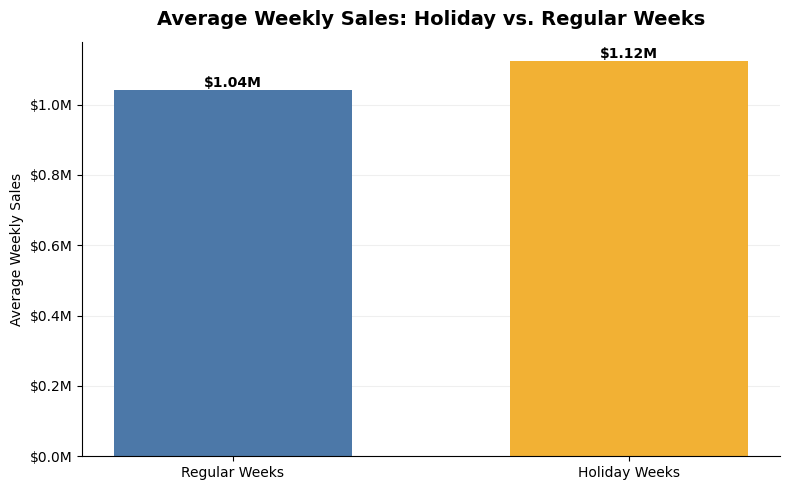

In [61]:
# Average weekly sales for regular and holiday weeks
holiday_comparison = (
    df.groupby("Holiday_Flag")["Weekly_Sales"]
      .mean()
      .reindex([0, 1])
)

holiday_labels = ["Regular Weeks", "Holiday Weeks"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    holiday_labels,
    holiday_comparison.values,
    color=["#4C78A8", "#F2B134"],
    width=0.6
)

ax.set_title(
    "Average Weekly Sales: Holiday vs. Regular Weeks",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_ylabel("Average Weekly Sales")

# Format y-axis as dollars in millions
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x / 1_000_000:.1f}M")
)

# Add values above bars
for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value / 1_000_000:.2f}M",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Average weekly sales per store are visibly higher during holiday weeks than during regular weeks. This visual pattern is consistent with the paired-samples t-test, which found a statistically significant difference between the two periods. While the results suggest that holiday periods are associated with stronger sales, other seasonal and business factors may also contribute to the increase.

---



**Which Stores Benefit Most During Holidays?**

This analysis compares each store’s average holiday-week sales with its average regular-week sales to identify which stores experience the largest increase during holiday periods.


In [62]:
pd.read_sql_query("""
SELECT
    Store,
    AVG(CASE
        WHEN Holiday_Flag = 1 THEN Weekly_Sales
    END) AS Holiday_Avg_Sales,

    AVG(CASE
        WHEN Holiday_Flag = 0 THEN Weekly_Sales
    END) AS Regular_Avg_Sales,

    AVG(CASE
        WHEN Holiday_Flag = 1 THEN Weekly_Sales
    END)
    -
    AVG(CASE
        WHEN Holiday_Flag = 0 THEN Weekly_Sales
    END) AS Sales_Difference,
   ROUND(
    (
        AVG(CASE WHEN Holiday_Flag = 1 THEN Weekly_Sales END)
        -
        AVG(CASE WHEN Holiday_Flag = 0 THEN Weekly_Sales END)
    )
    /
    AVG(CASE WHEN Holiday_Flag = 0 THEN Weekly_Sales END)
    * 100,
    2
) AS Holiday_Lift_Percent

FROM walmart_sales
GROUP BY Store
ORDER BY Sales_Difference DESC;

""",conn)

,Store,Holiday_Avg_Sales,Regular_Avg_Sales,Sales_Difference,Holiday_Lift_Percent
0,10,2113755.949,1.883309e+06,230446.517421,12.24
1,28,1478244.605,1.311889e+06,166355.623571,12.68
2,35,1074348.457,9.080992e+05,166249.302789,18.31
3,2,2079266.900,1.914209e+06,165058.088120,8.62
4,4,2243102.624,2.083556e+06,159546.780842,7.66
5,20,2249035.081,2.097048e+06,151986.647541,7.25
6,19,1577046.734,1.435071e+06,141976.096707,9.89
7,12,1138140.420,9.992919e+05,138848.495564,13.89
8,24,1475098.251,1.347857e+06,127240.816639,9.44
9,27,1892299.278,1.766413e+06,125886.314842,7.13


Store 10 had the largest absolute holiday increase. However, store 7 has the largest percentage increase.

---



**Which Months Have the Highest Average Weekly Sales?**

This analysis compares average weekly sales by month to identify seasonal patterns and determine which months tend to generate stronger weekly sales performance.

In [63]:
pd.read_sql_query("""
SELECT
    strftime('%m', Date) AS Month_Number,
    AVG(Weekly_Sales) AS Avg_Weekly_Sales,
    COUNT(*) AS Observations
FROM walmart_sales
GROUP BY Month_Number
ORDER BY Avg_Weekly_Sales DESC;

""", conn)

,Month_Number,Avg_Weekly_Sales,Observations
0,12,1.281864e+06,450
1,11,1.147266e+06,360
2,06,1.064325e+06,585
3,02,1.053200e+06,540
4,08,1.048017e+06,585
5,07,1.031748e+06,630
6,05,1.031714e+06,540
7,04,1.026762e+06,630
8,03,1.013309e+06,585
9,10,9.996321e+05,585


# **Holiday Sales: Statistical Significance**
Holiday weeks show higher average sales than regular weeks in the dataset. To determine whether this difference is statistically significant, a paired-samples t-test is used to compare each store’s average holiday-week sales with the same store’s average regular-week sales.



Average holiday-week sales are approximately \$1.12 million per store, compared with approximately \$1.04 million during regular weeks.


In [64]:

store_holiday = (
    df.groupby(["Store", "Holiday_Flag"])["Weekly_Sales"]
      .mean()
      .unstack()
)

t_stat, p_value = stats.ttest_rel(
    store_holiday[1],
    store_holiday[0]
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 9.652455490862085
P-value: 1.966293307021727e-12


Statistical Test Result

The paired-samples t-test produced a t-statistic of approximately 9.65 and a p-value of approximately 1.97 × 10⁻¹², which is well below the 0.05 significance level.

This provides strong statistical evidence that average sales differ between holiday and regular weeks across the stores in the dataset. However, statistical significance alone does not establish that holidays directly caused the increase in sales. Other seasonal or business-related factors may also contribute to the difference.



---



# **Economic/Environmental Factors**


**Temperature, Fuel Price, CPI, and Unemployment**

This analysis examines whether temperature, fuel prices, CPI, and unemployment are associated with weekly sales. Pearson correlation coefficients are used to measure the strength and direction of the linear relationship between each factor and weekly sales.


In [65]:
factors = ["Weekly_Sales", "Temperature", "Fuel_Price", "CPI", "Unemployment"]
factors_relationship = df[factors].corr()
factors_relationship["Weekly_Sales"].sort_values(ascending=False)

,Weekly_Sales
Weekly_Sales,1.000000
Fuel_Price,0.009464
Temperature,-0.063810
CPI,-0.072634
Unemployment,-0.106176


Correlation Results

The analysis produced the following correlations with weekly sales:

1. Fuel Price: very weak positive relationship, r = 0.009
2. Temperature: very weak negative relationship, r = -0.064
3. CPI: very weak negative relationship, r = -0.073
4. Unemployment: weak negative relationship, r = -0.106

All four correlation coefficients are close to zero, indicating weak linear relationships with weekly sales. Based on this analysis, none of these variables alone explains a large portion of the variation in sales.

However, these results do not mean that the factors have no effect on sales. They only indicate that none shows a strong standalone linear relationship with weekly sales in this dataset. Correlation also does not establish causation.



---

Sales Distribution Analysis

Distribution of Weekly Sales

This analysis examines the distribution of weekly sales to understand typical sales levels, variability, and the presence of unusually high or low observations.

The average weekly sales per store are approximately \$1.047 million, while the median is approximately \$961,000. Because the mean is higher than the median, larger sales observations are pulling the average upward.

The standard deviation is approximately \$564,000, indicating substantial variation in weekly sales across stores and time periods. The middle 50% of observations range from approximately \$553,000 to \$1.42 million, further demonstrating the wide variation in store-week performance.

The skewness value of 0.668 indicates that the distribution is moderately right-skewed. This means that while most observations are concentrated at lower and middle sales levels, several high-sales observations extend the upper end of the distribution.


## Store-Level Variation in Weekly Sales

The correlation analysis showed that temperature, fuel prices, CPI, and unemployment each have only weak linear relationships with weekly sales.

Since store performance varies considerably across locations, the next step is to measure how much of the overall variation in weekly sales is associated with differences between store averages.

To do this, an eta-squared effect size is calculated. This compares the variation between store-level average sales with the total variation in weekly sales.

This is used as a descriptive measure of store-level differences rather than as evidence that store identity alone causes changes in sales.

In [66]:
grand_mean = df["Weekly_Sales"].mean()

store_summary = (
    df.groupby("Store")["Weekly_Sales"]
      .agg(["count", "mean"])
)

ss_between = (
    store_summary["count"]
    * (store_summary["mean"] - grand_mean) ** 2
).sum()

ss_total = (
    (df["Weekly_Sales"] - grand_mean) ** 2
).sum()

eta_squared_store = ss_between / ss_total

print(f"Store-level eta-squared: {eta_squared_store:.3f}")
print(f"Percentage of sales variation associated with store differences: {eta_squared_store * 100:.1f}%")

Store-level eta-squared: 0.917
Percentage of sales variation associated with store differences: 91.7%


### Interpretation

The store-level eta-squared result shows that a substantial share of the variation in weekly sales is associated with differences between stores.

This is considerably more informative than the weak individual correlations observed for temperature, fuel prices, CPI, and unemployment. Within this dataset, store-level differences appear to be an important source of variation in weekly sales.

This does not mean that store identity directly causes higher or lower sales. Store differences may reflect factors not included in the dataset, such as store size, location, customer demand, product mix, or local market conditions.

In [67]:
df["Weekly_Sales"].describe()

,Weekly_Sales
count,6.435000e+03
mean,1.046965e+06
std,5.643666e+05
min,2.099862e+05
25%,5.533501e+05
50%,9.607460e+05
75%,1.420159e+06
max,3.818686e+06


# Calculating the Key Numbers Separately:

In [68]:
mean = df["Weekly_Sales"].mean()
median = df["Weekly_Sales"].median()
std = df["Weekly_Sales"].std()

q1 = df["Weekly_Sales"].quantile(0.25)
q3 = df["Weekly_Sales"].quantile(0.75)

iqr = q3 - q1

skew = df["Weekly_Sales"].skew()

print("Mean:", mean)
print("Median:", median)
print("Standard Deviation:", std)
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Skewness:", skew)

Mean: 1046964.8775617715
Median: 960746.04
Standard Deviation: 564366.6220536974
Q1: 553350.105
Q3: 1420158.66
IQR: 866808.5549999999
Skewness: 0.6683617974864524


**Distribution of Walmart Weekly Sales:**

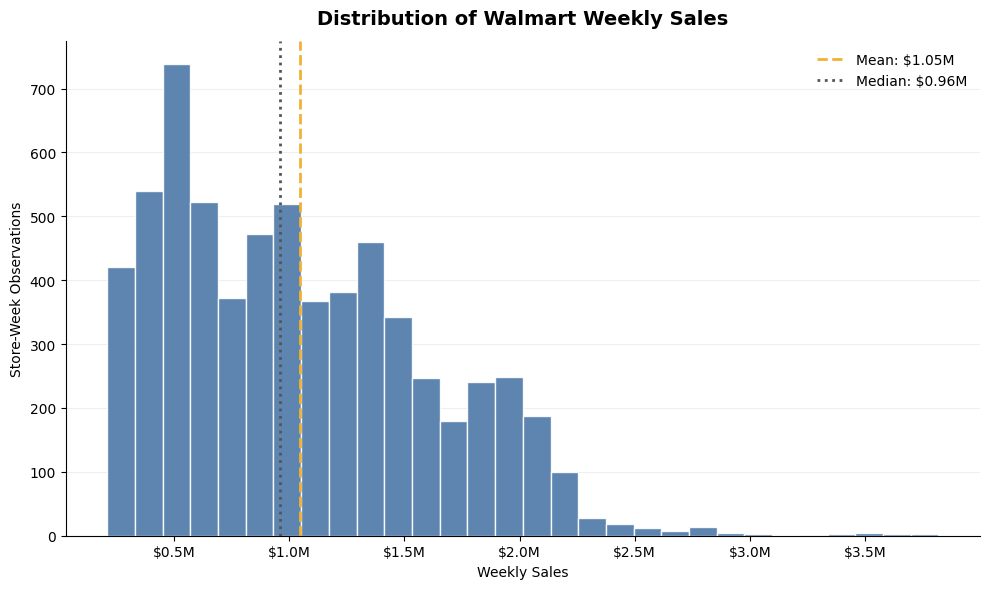

In [69]:
mean_sales = df["Weekly_Sales"].mean()
median_sales = df["Weekly_Sales"].median()

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["Weekly_Sales"],
    bins=30,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.9
)

# Mean and median reference lines
ax.axvline(
    mean_sales,
    color="#F2B134",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_sales / 1_000_000:.2f}M"
)

ax.axvline(
    median_sales,
    color="#555555",
    linestyle=":",
    linewidth=2,
    label=f"Median: ${median_sales / 1_000_000:.2f}M"
)

ax.set_title(
    "Distribution of Walmart Weekly Sales",
    fontsize=14,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Weekly Sales")
ax.set_ylabel("Store-Week Observations")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"${x / 1_000_000:.1f}M")
)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

Conclusion:

Mean:	\$1,046,964.88 (Average weekly sales)

Median	\$960,746.04	(Typical middle observation)

Std. deviation	\$564,366.62	(Large variation in weekly sales)

Q1: \$553,350.11
25% of store-week observations had sales below this value.

Q3: \$1,420,158.66
75% of store-week observations had sales below this value.

IQR	\$866,808.55	(Spread of the middle 50%)

Skewness	0.668	(Moderately right-skewed)

Minimum	\$209,986.25	(Lowest weekly sales)

Maximum	\$3,818,686.45	(Highest weekly sales)



---

# **Statistical and Business Analysis Conclusion**

The statistical and business analysis provides a clearer understanding of Walmart’s weekly sales performance across the 45 stores in the dataset.

Store performance varies considerably across locations, with 19 stores recording average weekly sales above the overall average and 26 stores falling below it. This suggests that company-wide averages alone may hide meaningful differences between individual store locations.

Holiday weeks also recorded higher average sales than regular weeks. A paired-samples t-test produced a t-statistic of approximately 9.65 and a p-value below 0.001, providing strong statistical evidence of a difference between holiday and regular-week sales. However, this relationship should not be interpreted as proof that holidays directly caused the increase.

The economic and environmental variables included in the dataset showed only weak linear relationships with weekly sales. Temperature, fuel prices, CPI, and unemployment all produced correlation coefficients close to zero, suggesting that these variables alone do not explain much of the variation in sales.

Weekly sales also showed substantial variability. Average weekly sales per store were approximately \$1.047 million, compared with a median of approximately \$961,000 and a standard deviation of approximately \$564,000. The positive skewness of 0.668 indicates that higher-sales observations pull the overall average upward.

Overall, the findings suggest that store-level differences, timing, and holiday periods are important areas to consider when evaluating Walmart’s weekly sales performance.



---



# **Business Insights**

The analysis identified several meaningful patterns in Walmart’s weekly sales performance.

First, sales performance varies significantly across individual stores. Of the 45 stores analyzed, 19 recorded average weekly sales above the overall average, while 26 fell below it. This shows that performance is not evenly distributed across locations and that company-wide averages can hide important store-level differences.

Holiday weeks also produced higher average sales than regular weeks. The paired statistical test found a significant difference between the two periods, suggesting that holiday periods are an important consideration when planning inventory, staffing, and other store resources. However, the analysis does not establish that holidays alone caused the increase in sales.

The sales distribution also shows substantial variation across store-week observations. The average weekly sales per store were approximately 1.047 million, while the median was approximately $961,000. This difference, along with a standard deviation of approximately \$564,000 and positive skewness of 0.668, indicates that some high-sales observations pull the average upward.

Finally, temperature, fuel prices, CPI, and unemployment showed only weak linear relationships with weekly sales. This suggests that these variables alone are not sufficient to explain Walmart’s sales performance and that additional factors such as store characteristics, promotions, local demand, product mix, and seasonal events may provide greater explanatory value.